In [9]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os


In [12]:
# Define parameters and load data using configurable paths

# Function to load data from file
def load_data(file_path):
    return pd.read_csv(file_path, sep='\t', decimal=',')

base_path = r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers'

file_paths = {
    'data_3_5_along': os.path.join(base_path, r'2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New', r'output_along_3_5_full.ascii'),
    'data_3_5_trans': os.path.join(base_path, r'2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New', r'output_trans_3_5_full.ascii'),
    'data_6_along': os.path.join(base_path, r'2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um', r'output_along_6_full.ascii'),
    'data_6_trans': os.path.join(base_path, r'2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um', r'output_trans_6_full.ascii'),
    'data_12_along': os.path.join(base_path, r'2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um', r'output_along_12_full.ascii'),
    'data_12_trans': os.path.join(base_path, r'2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um', r'output_trans_12_full.ascii')
}

data_3_5_along = load_data(file_paths['data_3_5_along'])
data_3_5_trans = load_data(file_paths['data_3_5_trans'])
data_6_along = load_data(file_paths['data_6_along'])
data_6_trans = load_data(file_paths['data_6_trans'])
data_12_along = load_data(file_paths['data_12_along'])
data_12_trans = load_data(file_paths['data_12_trans'])

In [2]:
'''data_3_5_along =  pd.read_csv(r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New\output_along_3_5_full.ascii', sep='\t', decimal=',')
data_3_5_trans = pd.read_csv(r"C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.05.17_SPR+microscopy on InSb+Gr-3.5 layaer_197 um_New\output_trans_3_5_full.ascii", sep='\t', decimal=',')
data_6_along = pd.read_csv(r"C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um\output_along_6_full.ascii", sep='\t', decimal=',')
data_6_trans = pd.read_csv(r"C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um\output_trans_6_full.ascii", sep='\t', decimal=',')
data_12_along = pd.read_csv(r"C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um\output_along_12_full.ascii", sep='\t', decimal=',')
data_12_trans = pd.read_csv(r"C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um\output_trans_12_full.ascii", sep='\t', decimal=',')'''


In [13]:
n_prism = complex(1.531, -0.002)                   # комплексный показатель преломления призмы (Zeonex)
eps_prism = n_prism**2                             # диэлектрическая проницаемость призмы (Zeonex)
eps_air = n = 1                                    # диэлектрическая проницаемость воздуха (1.00027717)
eps_InSb = complex(-17.3, 7.12)                    # InSb на 197мкм из Telegram
wavelength = 197 * 10**(-6)                        # длина волны лазера в метрах
d_layer = 35 * 10**(-9)                            # толщина графеновой плёнки в метрах
step = 0.083*10**(-6)                              # шаг в метрах 

# -18.474508935284483+0.006568625288807081j - InSb по Друде-Лоренцу
# угол и зазор подгоняется из условия резонанса, т.к. гониометр и "линейка" неточные (???)
# какая точность нужна для расчётов? 

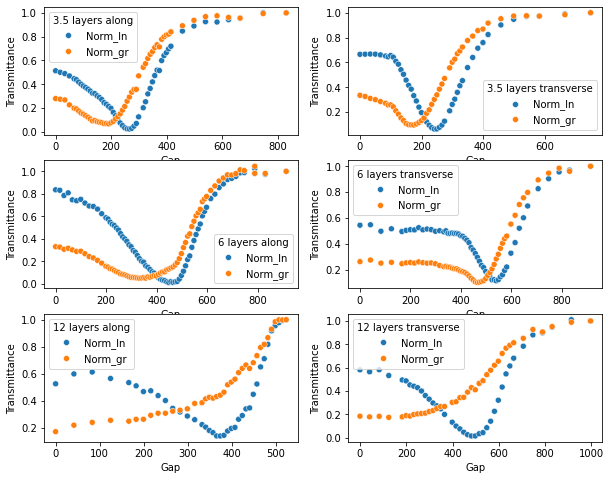

In [14]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8)) 

al_3_5_melted = data_3_5_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='3.5 layers along', value_name='Transmittance')
sns.scatterplot(data = al_3_5_melted, x="Gap", y="Transmittance", hue="3.5 layers along", ax=axs[0, 0])
tr_3_5_melted = data_3_5_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='3.5 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_3_5_melted, x="Gap", y="Transmittance", hue="3.5 layers transverse", ax=axs[0, 1])
al_6_melted = data_6_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='6 layers along', value_name='Transmittance')
sns.scatterplot(data = al_6_melted, x="Gap", y="Transmittance", hue="6 layers along", ax=axs[1, 0])
tr_6_melted = data_6_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='6 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_6_melted, x="Gap", y="Transmittance", hue="6 layers transverse", ax=axs[1, 1])
al_12_melted = data_12_along.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='12 layers along', value_name='Transmittance')
sns.scatterplot(data = al_12_melted, x="Gap", y="Transmittance", hue="12 layers along", ax=axs[2, 0])
tr_12_melted = data_12_trans.melt(id_vars='Gap', value_vars=['Norm_In', 'Norm_gr'],var_name='12 layers transverse', value_name='Transmittance')
sns.scatterplot(data = tr_12_melted, x="Gap", y="Transmittance", hue="12 layers transverse", ax=axs[2, 1])
plt.show()

# изменить ось x


In [15]:
# Код Герасимова
def reflect3(gap_arr, angle, re_InSb, im_InSb):
    eps_InSb = complex(re_InSb, im_InSb)
    kz_prism=np.sqrt(eps_prism)*np.cos(angle)
    kz_air=np.sqrt(eps_air-eps_prism*np.sin(angle)**2)
    kz_3=np.sqrt(eps_InSb-eps_prism*np.sin(angle)**2)
    
#Коэффициенты отражения
    r_12=(eps_air*kz_prism-eps_prism*kz_air)/(eps_air*kz_prism+eps_prism*kz_air)
    r_23=(eps_InSb*kz_air-eps_air*kz_3)/(eps_InSb*kz_air+eps_air*kz_3)

#Коэффициенты пропускания
    t_12=2*kz_prism*np.sqrt(eps_prism*eps_air)/(eps_air*kz_prism+eps_prism*kz_air) #???
    t_23=2*kz_air*np.sqrt(eps_air*eps_InSb)/(eps_InSb*kz_air+eps_air*kz_3)
   
 #Матрица пропускания
    S1=np.array([[1/t_12, r_12/t_12], [r_12/t_12, 1/t_12]])    
    
#Расчёт R    
    R = []
    for j in range(len(gap_arr)):   
        S2=np.array([[np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23, 
          r_23*np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23],  
          [r_23*np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23, 
          np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23]])
        print(S2)
        S=S1@S2
        R += [abs(S[1][0]/S[0][0])]
    return(np.array(R))

In [16]:
# Код Герасимова 
def reflect4(gap, n, eps_re, eps_im, angle): #number: of layers
    d_gr = n*d_layer
    eps_gr = complex(eps_re, eps_im) 
    kz_prism=np.sqrt(eps_prism)*np.cos(angle)
    kz_air=np.sqrt(eps_air-eps_prism*np.sin(angle)**2)
    kz_3=np.sqrt(eps_gr-eps_prism*np.sin(angle)**2)
    kz_InSb=np.sqrt(eps_InSb-eps_prism*np.sin(angle)**2)
    

#Коэффициенты отражения
    r_12=(eps_air*kz_prism-eps_prism*kz_air)/(eps_air*kz_prism+eps_prism*kz_air)
    r_23=(eps_gr*kz_air-eps_air*kz_3)/(eps_gr*kz_air+eps_air*kz_3)
    r_34=(eps_InSb*kz_3-eps_gr*kz_InSb)/(eps_InSb*kz_3+eps_gr*kz_InSb)

#Коэффициенты пропускания
    t_12=2*kz_prism*np.sqrt(eps_prism*eps_air)/(eps_air*kz_prism+eps_prism*kz_air)
    t_23=2*kz_air*np.sqrt(eps_air*eps_gr)/(eps_gr*kz_air+eps_air*kz_3)
    t_34=2*kz_3*np.sqrt(eps_gr*eps_InSb)/(eps_InSb*kz_3+eps_gr*kz_InSb)

#Матрица преобразования
    S1=np.array([[1/t_12, r_12/t_12], [r_12/t_12, 1/t_12]])
    S3=np.array([[np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_3*d_gr)/t_34,
      r_34*np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_3*d_gr)/t_34],
      [r_34*np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_3*d_gr)/t_34, 
      np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_3*d_gr)/t_34]])
    R = []
    for j in range(len(gap)):   
        S2=np.array([[np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap[j])/t_23, r_23*np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap[j])/t_23],  [r_23*np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap[j])/t_23, np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap[j])/t_23]])
        S=np.dot(np.dot(S1, S2), S3)
        R += [abs(S[1][0]/S[0][0])]
    
    return np.array(R)

[[ 3.38070879-3.46282254j  1.05932309+2.56371522j]
 [-2.29043628-0.96398754j  0.03118174+4.3352894j ]]
[[ 3.2327016 -3.61463312j  1.17275261+2.5200917j ]
 [-2.24154288-1.06101407j -0.15801401+4.32369368j]]
[[ 3.07788547-3.76012552j  1.28439418+2.47145308j]
 [-2.18856336-1.15561794j -0.34613855+4.30388001j]]
[[ 2.91652974-3.89899468j  1.39402622+2.41787227j]
 [-2.1316156 -1.24762816j -0.53283663+4.27591968j]]
[[ 2.74891744-4.03094704j  1.50143011+2.35943192j]
 [-2.0708246 -1.33687939j -0.71775716+4.23989926j]]
[[ 2.57534472-4.1557011j   1.60639059+2.29622436j]
 [-2.00632219-1.42321222j -0.90055388+4.19592038j]]
[[ 2.39612043-4.27298801j  1.70869623+2.22835147j]
 [-1.93824676-1.5064735j  -1.08088598+4.14409944j]]
[[ 2.21156547-4.38255217j  1.80813984+2.15592446j]
 [-1.86674297-1.58651655j -1.25841877+4.0845674j ]]
[[ 2.02201234-4.48415178j  1.90451886+2.07906376j]
 [-1.79196144-1.66320145j -1.43282426+4.0174694j ]]
[[ 1.82780444-4.57755931j  1.99763579+1.99789881j]
 [-1.71405844-1.736395

C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:24: RuntimeWarning: overflow encountered in exp
  [r_23*np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23,
C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:24: RuntimeWarning: invalid value encountered in cdouble_scalars
  [r_23*np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23,
C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:25: RuntimeWarning: overflow encountered in exp
  np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23]])
C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:25: RuntimeWarning: invalid value encountered in cdouble_scalars
  np.exp(complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23]])
C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:28: RuntimeWarning: invalid value encountered in cdouble_scalars
  R += [abs(S[1][0]/S[0][0])]


[[ 2.35812128-5.06498739j  2.49670005+0.24049596j]
 [-2.25478446-0.24218407j -2.18211786+4.55567179j]]
[[ 2.09285281-5.19034384j  2.51008058+0.10945892j]
 [-2.23523571-0.35945502j -2.41389723+4.42757819j]]
[[ 1.82092165-5.30180795j  2.51658398-0.02232022j]
 [-2.20960891-0.47534535j -2.63826597+4.28774437j]]
[[ 1.54305534-5.39902566j  2.5161692 -0.15448052j]
 [-2.17799485-0.58954116j -2.85463222+4.13659398j]]
[[ 1.26000021-5.48168101j  2.50881416-0.28665882j]
 [-2.14050047-0.70173427j -3.0624281 +3.97458035j]]
[[ 0.9725194 -5.54949714j  2.49451581-0.41849066j]
 [-2.09724851-0.81162301j -3.26111119+3.80218513j]]
[[ 0.68139085-5.60223717j  2.47329026-0.54961132j]
 [-2.04837712-0.91891308j -3.45016592+3.61991691j]]
[[ 0.68139085-5.60223717j  2.47329026-0.54961132j]
 [-2.04837712-0.91891308j -3.45016592+3.61991691j]]
[[-0.80097441-5.63439478j  2.26515586-1.1818896j ]
 [-1.72558556-1.40669311j -4.23501004+2.57997309j]]
[[ 5.26989771-1.30881988j  1.34233055+2.03489976j]
 [-1.65117231+1.648659

C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:22: RuntimeWarning: overflow encountered in exp
  S2=np.array([[np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23,
C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:22: RuntimeWarning: invalid value encountered in cdouble_scalars
  S2=np.array([[np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23,
C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:23: RuntimeWarning: overflow encountered in exp
  r_23*np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23],
C:\Users\belco\AppData\Local\Temp\ipykernel_1468\2156491958.py:23: RuntimeWarning: invalid value encountered in cdouble_scalars
  r_23*np.exp(-complex(0, 1)*(2*np.pi/wavelength)*kz_air*gap_arr[j])/t_23],


[[-10.27936275-1.60910746j  -2.16180794+0.57522056j]
 [ -0.94879357+1.24009094j  -6.36497491+3.49678122j]]
[[-10.35719476-1.22586674j  -2.14387192+0.65736596j]
 [ -0.99220011+1.20080188j  -6.47596387+3.24812109j]]
[[-10.42076881-0.83905439j  -2.12282114+0.73897707j]
 [ -1.03400427+1.16001227j  -6.57731766+2.99608232j]]
[[-10.46992664-0.44919969j  -2.09867039+0.81993602j]
 [ -1.07415494+1.11778662j  -6.6689398 +2.74103542j]]
[[-10.50452958-0.0568388j   -2.0714389 +0.90012531j]
 [ -1.11260357+1.07419117j  -6.75074798+2.48335332j]]
[[-10.52445889+0.33748602j  -2.04115036+0.97942797j]
 [ -1.14930423+1.02929374j  -6.82267407+2.22341092j]]
[[-10.52961597+0.73322716j  -2.00783288+1.0577277j ]
 [ -1.18421367+0.9831637j   -6.88466417+1.96158448j]]
[[-10.5199226 +1.12983233j  -1.97151898+1.13490908j]
 [ -1.21729137+0.93587178j  -6.93667858+1.69825111j]]
[[-10.4953212 +1.5267454j   -1.93224557+1.21085771j]
 [ -1.24849958+0.88749002j  -6.97869184+1.43378826j]]
[[-10.45577493+1.92340714j  -1.890053

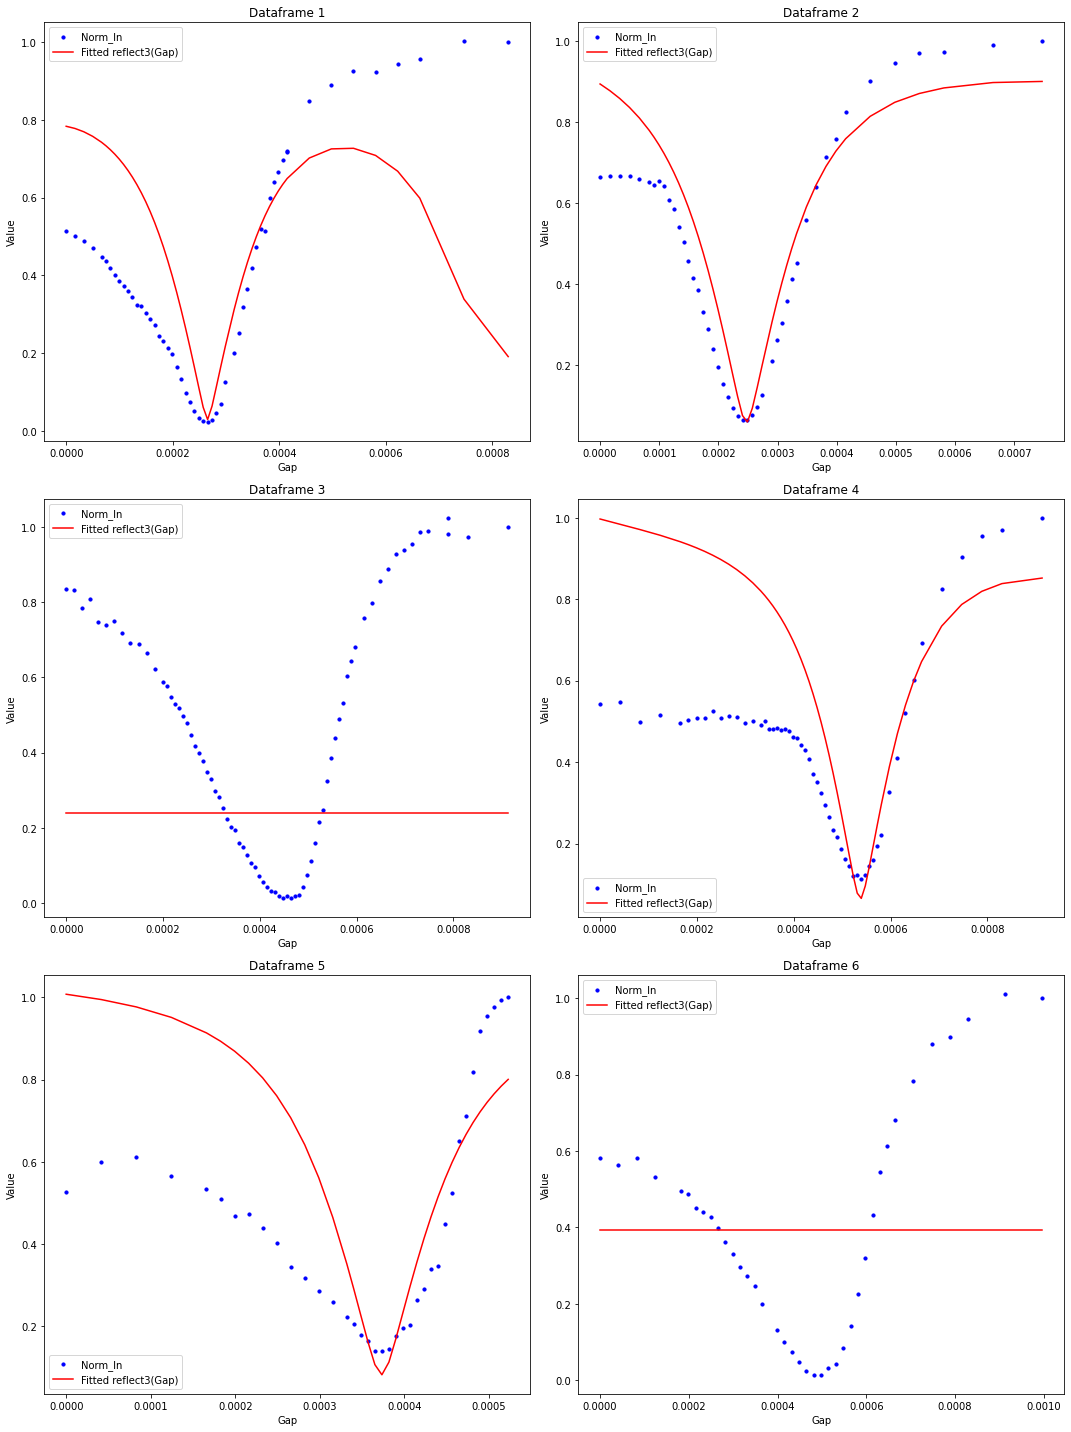

In [17]:
# почему красные линии разные?
# сначала вручную угол, потом фиттинг



def fitting_function(x, shift, angle, re_InSb, im_InSb):
    return reflect3(x-np.ones(x.size)*shift, angle, re_InSb, im_InSb)

# Dataframes 
dfs = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans,data_12_along, data_12_trans]


# Create a figure for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for i, df in enumerate(dfs):
    gap = df['Gap'].values*10**(-6)
    norm_in = df['Norm_In'].values

    # Fit the fitting function to the data
    initial_guess = [0, 0.7, -7, 17]  # Initial guesses for [shift, angle, re_InSb, im_InSb]
    min, max = (norm_in.argmin()-5, norm_in.argmin()+20) 
    params, _ = curve_fit(fitting_function, gap[min:max], norm_in[min:max], p0=initial_guess)
    print(params)

    # Plot the original data
    axes[i].scatter(gap, norm_in, color='blue', label='Norm_In', s=10)

    # Plot the fitted function
    



    fitted_values = fitting_function(gap, *params)
    axes[i].plot(gap, fitted_values, color='red', label='Fitted reflect3(Gap)')

    # Set subplot title and labels
    axes[i].set_title(f'Dataframe {i+1}')
    axes[i].set_xlabel('Gap')
    axes[i].set_ylabel('Value')
    axes[i].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

TypeError: 'numpy.int64' object is not callable

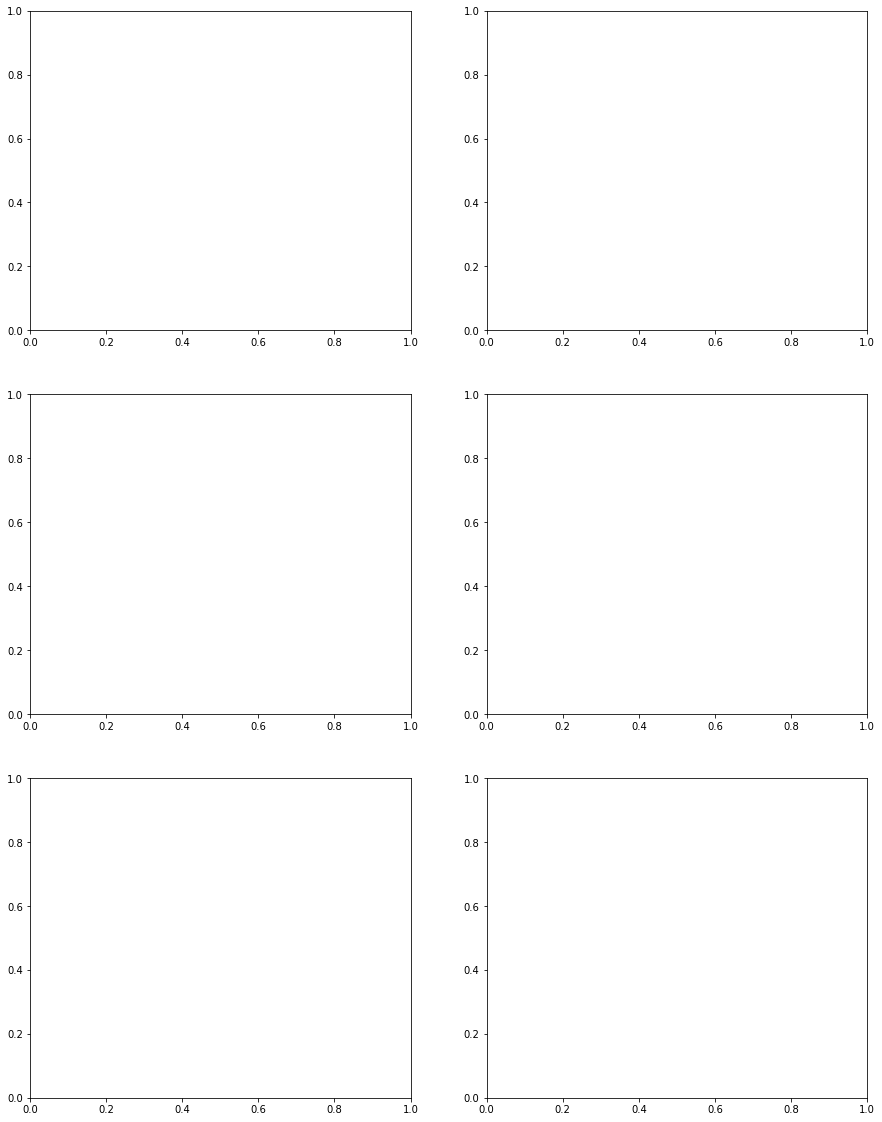

In [18]:
# gpt numeric precision

# почему красные линии разные?
# сначала вручную угол, потом фиттинг


def fitting_function(x, shift, angle, re_InSb, im_InSb):
    return reflect3(x - np.ones(x.size, dtype=np.float64) * shift, angle, re_InSb, im_InSb)

# Dataframes 
dfs = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans, data_12_along, data_12_trans]

# Create a figure for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for i, df in enumerate(dfs):
    gap = df['Gap'].values.astype(np.float64) * 10**(-6)
    norm_in = df['Norm_In'].values.astype(np.float64)

    # Dynamic initial guesses based on data statistics
    shift_guess = gap.mean()
    angle_guess = 0.7  # Keeping as a constant guess, or adjust based on context
    re_InSb_guess = norm_in.min()
    im_InSb_guess = norm_in.max() - norm_in.min()
    initial_guess = [shift_guess, angle_guess, re_InSb_guess, im_InSb_guess]

    # Ensure min_index and max_index are within bounds
    min_index = max(norm_in.argmin() - 5, 0)
    max_index = min(norm_in.argmin() + 20, len(gap))
    
    try:
        params, _ = curve_fit(fitting_function, gap[min_index:max_index], norm_in[min_index:max_index], p0=initial_guess)
        print(params)
    except RuntimeError as e:
        print(f"Fitting failed for Dataframe {i+1}: {e}")
        params = initial_guess

    # Validate params before using them in the fitting function
    if not np.any(np.isnan(params)) and not np.any(np.isinf(params)):
        # Plot the original data
        axes[i].scatter(gap, norm_in, color='blue', label='Norm_In', s=5, alpha=0.6)

        # Plot the fitted function
        fitted_values = fitting_function(gap, *params)
        if not np.any(np.isnan(fitted_values)) and not np.any(np.isinf(fitted_values)):
            axes[i].plot(gap, fitted_values, color='red', label='Fitted reflect3(Gap)')
        else:
            print(f"Invalid fitted values for Dataframe {i+1}, skipping plot.")
    else:
        print(f"Invalid fitting parameters for Dataframe {i+1}, skipping plot.")

    # Set subplot title and labels
    axes[i].set_title(f'Dataframe {i+1}')
    axes[i].set_xlabel('Gap')
    axes[i].set_ylabel('Value')
    axes[i].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()  



In [ ]:

# сначала вручную угол, потом фиттинг



def fitting_function(x, shift, angle):
    return reflect3(x-np.ones(x.size)*shift, angle, eps_InSb.real, eps_InSb.imag)

# Dataframes 
dfs = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans,data_12_along, data_12_trans]


# Create a figure for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for i, df in enumerate(dfs):
    gap = df['Gap'].values*10**(-6)
    norm_in = df['Norm_In'].values

    # Fit the fitting function to the data
    initial_guess = [0, 0.7]  # Initial guesses for [shift, angle, re_InSb, im_InSb]
    #min, max = (norm_in.argmin()-5, norm_in.argmin()+20) 
    params, _ = curve_fit(fitting_function, gap, norm_in, p0=initial_guess)
    print(params)

    # Plot the original data
    axes[i].scatter(gap, norm_in, color='blue', label='Norm_In', s=10)

    # Plot the fitted function
    


    fitted_values = fitting_function(gap, *params)
    axes[i].plot(gap, fitted_values, color='red', label='Fitted reflect3(Gap)')

    # Set subplot title and labels
    axes[i].set_title(f'Dataframe {i+1}')
    axes[i].set_xlabel('Gap')
    axes[i].set_ylabel('Value')
    axes[i].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
'''from scipy.optimize import curve_fit

dataframes = [data_3_5_along, data_3_5_trans, data_6_along, data_6_trans,data_12_along, data_12_trans]


# Closure to override eps_InSb during fitting
def create_fitting_function():
    def fitting_function(x, angle, shift, real_eps, imag_eps):
        original_eps = eps_InSb  # Store original global value

        # Temporarily override eps_InSb with fitted values
        eps_InSb = real_eps + 1j * imag_eps

        # Compute reflect3 with the temporary eps_InSb and additional shift
        result = reflect3(x-np.ones(x.size)*shift, angle)

        # Restore original global value
        eps_InSb = original_eps

        return result
    return fitting_function

# Function to fit parameters for multiple DataFrames and plot subplots
def fit_and_plot(dataframes):
    global eps_InSb
    # Create a fitting function that uses the closure
    fitting_function = create_fitting_function()

    # Create a 2x3 grid of subplots
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.ravel()

    # Iterate over each DataFrame and fit the parameters
    for i, df in enumerate(dataframes):
        x_data = df['Gap'].values*10**(-6)
        print(x_data)
        y_data = df['Norm_In'].values

        

        # Initial guess for parameters: [angle, shift, real_eps, imag_eps]
        initial_guess = [0.5, 0, -7, 17]

        # Perform curve fitting
        popt, pcov = curve_fit(fitting_function, x_data, y_data, p0=initial_guess)
        fitted_angle, fitted_shift, fitted_real_eps, fitted_imag_eps = popt
        print(popt)


         # Compute fitted y values using the fitted parameters
        fitted_eps_InSb = complex(fitted_real_eps, fitted_imag_eps)
        print(eps_InSb)
        original_eps = eps_InSb  # Store original global value
        eps_InSb = fitted_eps_InSb
        y_fitted = reflect3(x_data-np.ones(x_data.size)*fitted_shift, fitted_angle)
       
        

        # Plotting
        axs[i].plot(x_data, y_data, 'b.', label='Norm_In (Data)')
        axs[i].plot(x_data, y_fitted, 'r-', label='Fitted reflect3')
        
        
        print(fitted_angle)
        #axs[i].plot(x_data, reflect3(x_data, fitted_angle), 'r-', label='Fitted reflect3')
        eps_InSb = original_eps  # Restore original global value
        axs[i].set_title(f'DataFrame {i+1}')
        axs[i].set_xlabel('Gap')
        axs[i].set_ylabel('Norm_In')
        axs[i].legend()


    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Example usage: create 6 DataFrames with 'Gap' and 'Norm_In' columns


fit_and_plot(dataframes)'''

In [ ]:
print(eps_InSb)
x_data = data_3_5_trans['Gap'].values*10**(-6)
plt.plot(x_data, reflect3(x_data, 0.7))

In [ ]:
# Testing method on InSb: compare eps_InSb with value obtained by Fourier-spectrometry

# Using closure to store global eps_InSb while fitting

def fitting_function(x, angle, shift, local_re, local_im):
    global eps_InSb
    original_eps_InSb = eps_InSb  # Store the original global value
    eps_InSb = complex(local_re, local_im)   # Temporarily override with local_eps_InSb
    print(eps_InSb)
    
    # Compute the result using the temporary eps_InSb
    result = reflect3(x-np.ones(x.size)*shift, angle)
    eps_InSb = original_eps_InSb  # Restore the original global value
    
    return result


# Example fitting function
def fit_parameters(x_data, y_data):
    # Create the fitting function that will temporarily modify eps_InSb

    # Initial guess for 'angle' and 'eps_InSb'
    initial_guess = [0.7, 0, -17.3, 7.12]  # [angle, local_re, local_im]

    # Perform curve fitting for both 'angle' and 'eps_InSb'
    popt, pcov = scipy.optimize.curve_fit(fitting_function, x_data, y_data, p0 = initial_guess, bounds = ([0.6, 0.8],[0, 1], [-5, -500], [5, 500]))

    return popt, pcov

x_data = data_3_5_along['Gap'].values*10**(-6)
y_data = data_3_5_along['Norm_In'].values

popt, pcov = fit_parameters(x_data, y_data)
print(popt, pcov)
print(eps_InSb)
plt.plot(x_data, fitting_function(x_data, 7.05510336e-01, 6.21772911e-04, 2.56990770e+02, -1.45108626e+02))
plt.plot(x_data, y_data)
plt.show()

In [ ]:
# fitting angle and shift by InSb 

# The general fitting function
def fitting_function(x_column, angle, shift):
    return reflect3(x_column-np.ones(x_column.size)*shift, angle, eps_InSb.real, eps_InSb.imag)

# Extracting x and y data from the DataFrame
x_data = data_3_5_along['Gap'].values*10**(-6)
y_data = data_3_5_along['Norm_In'].values


# Fitting teta
#teta, shift = scipy.optimize.curve_fit(reflect3, x_column, y_column, p0=0.7)[0]
print(scipy.optimize.curve_fit(fitting_function, x_data, y_data, p0=(0.7, 0)))
min, max = (y_data.argmin()-5, y_data.argmin()+5) 
teta, shift = scipy.optimize.curve_fit(fitting_function, x_data[min:max], y_data[min:max], p0=(0.7, 0))[0]
print(teta, shift) #угол в градусах

plt.plot(x_data, fitting_function(x_data, teta, shift))
plt.plot(x_data, y_data)
plt.show()


In [ ]:
# InSb plots 

dfs = []




# Create another DataFrame
data2 = {
    'E': [2, 4, 6, 8, 10],
    'F': [10, 9, 8, 7, 6]
}
df2 = pd.DataFrame(data2)

# Create a 2x2 grid and plot data from both DataFrames
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

df['A'].plot(ax=axs[0, 0], title='A', color='blue')
df['B'].plot(ax=axs[0, 1], title='B', color='red')
df2['E'].plot(ax=axs[1, 0], title='E', color='green')
df2['F'].plot(ax=axs[1, 1], title='F', color='purple')

plt.tight_layout()
plt.show()

In [87]:
# fitting epsilon 


def fit_epsilon(x_column, y_column, n, angle):
  
    def fit_function(x, eps_re, eps_im):
        return reflect4(x, n, eps_re, eps_im, angle)
    
    return scipy.optimize.curve_fit(fit_function, x_column, y_column, bounds = ([-1000, -100], [10, 1000]))



In [ ]:
gr_3_5_al = data_3_5_along['Norm_gr'].values
gap_3_5_al = data_3_5_along['Gap'].values*10**(-6)
print(fit_epsilon(gap_3_5_al, gr_3_5_al, n, teta))
plt.plot(gap_3_5_al, reflect4(gap_3_5_al, 3.5, -332.99340746, 4061.89106971, 0.700131334))
plt.plot(gap_3_5_al+0.0001, gr_3_5_al)

gr_3_5_tr = data_3_5_trans['Norm_gr'].values
gap_3_5_tr = data_3_5_trans['Gap'].values*10**(-6)
print(fit_epsilon(gap_3_5_tr, gr_3_5_tr, n, teta))
plt.plot(gap_3_5_tr, reflect4(gap_3_5_tr, 3.5, -332.99340746, 4061.89106971, 0.700131334))
plt.plot(gap_3_5_tr+0.0001, gr_3_5_tr)

gr_6_al = data_6_along['Norm_gr'].values
gap_6_al = data_6_along['Gap'].values*10**(-6)
print(fit_epsilon(gap_6_al, gr_6_al, n, teta))
plt.plot(gap_6_al, reflect4(gap_6_al, 3.5, -332.99340746, 4061.89106971, 0.700131334))
plt.plot(gap_6_al+0.0001, gr_6_al)

gr_6_tr = data_6_trans['Norm_gr'].values
gap_6_tr = data_6_trans['Gap'].values*10**(-6)
print(fit_epsilon(gap_6_tr, gr_6_tr, n, teta))
plt.plot(gap_6_tr, reflect4(gap_6_tr, 3.5, -332.99340746, 4061.89106971, 0.700131334))
plt.plot(gap_6_tr+0.0001, gr_6_tr)

gr_12_al = data_12_along['Norm_gr'].values
gap_12_al = data_12_along['Gap'].values*10**(-6)
print(fit_epsilon(gap_12_al, gr_12_al, n, teta))
plt.plot(gap_12_al, reflect4(gap_12_al, 3.5, -332.99340746, 4061.89106971, 0.700131334))
plt.plot(gap_12_al+0.0001, gr_12_al)

gr_12_trans = data_12_trans['Norm_gr'].values
gap_12_tr = data_12_trans['Gap'].values*10**(-6)
print(fit_epsilon(gap_12_tr, gr_12_trans, n, teta))
plt.plot(gap_12_tr, reflect4(gap_12_tr, 3.5, -332.99340746, 4061.89106971, 0.700131334))
plt.plot(gap_12_tr+0.0001, gr_12_trans)
plt.show()

In [ ]:
gap_arr = x_data
print(x_data) 
plt.plot(gap_arr, reflect3(gap_arr, 0.72889286))
plt.plot(gap_arr, y_data)
plt.show()